# EDA

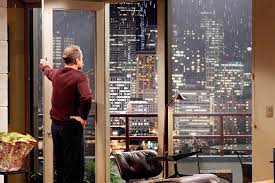

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [2]:
import pandas as pd
df_import = pd.read_csv("data/king_house.csv")
df_import.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,2014-10-13,221900.000
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,2014-12-09,538000.000
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,2015-02-25,180000.000
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,2014-12-09,604000.000
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,2015-02-18,510000.000


In [3]:
df_import["waterfront"].unique()
df_import["waterfront"].isna().sum()

np.int64(2391)

In [4]:
df_import["waterfront"].unique()


array([nan,  0.,  1.])

Need to decide whether to deleted or put 0 for waterfront value.

In [5]:
len(df_import)

21597

In [6]:
df_import["id"].duplicated().sum()


np.int64(177)

In [7]:
duplicates = df_import[df_import["id"].duplicated(keep=False)]
duplicates.sort_values("id")


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
2495,1000102,6.000,3.000,2400.000,9373.000,2.000,NaN,0.000,3,7,...,0.000,1991,0.000,98002,47.326,-122.214,2060.000,7316.000,2015-04-22,300000.000
2494,1000102,6.000,3.000,2400.000,9373.000,2.000,NaN,0.000,3,7,...,0.000,1991,0.000,98002,47.326,-122.214,2060.000,7316.000,2014-09-16,280000.000
16800,7200179,2.000,1.000,840.000,12750.000,1.000,0.000,0.000,3,6,...,0.000,1925,NaN,98055,47.484,-122.211,1480.000,6969.000,2014-10-16,150000.000
16801,7200179,2.000,1.000,840.000,12750.000,1.000,0.000,0.000,3,6,...,0.000,1925,NaN,98055,47.484,-122.211,1480.000,6969.000,2015-04-24,175000.000
11422,109200390,3.000,1.750,1480.000,3900.000,1.000,0.000,0.000,4,7,...,0.000,1980,0.000,98023,47.298,-122.367,1830.000,6956.000,2014-10-20,250000.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6339,9828200460,2.000,1.000,700.000,4800.000,1.000,0.000,0.000,3,7,...,0.000,1922,0.000,98122,47.615,-122.300,1440.000,4800.000,2014-06-27,260000.000
15186,9834200305,3.000,1.000,1790.000,3876.000,1.500,0.000,0.000,5,7,...,700.000,1904,0.000,98144,47.575,-122.288,1360.000,4080.000,2015-02-10,615000.000
15185,9834200305,3.000,1.000,1790.000,3876.000,1.500,0.000,0.000,5,7,...,700.000,1904,0.000,98144,47.575,-122.288,1360.000,4080.000,2014-07-16,350000.000
1084,9834200885,4.000,2.500,2080.000,4080.000,1.000,0.000,0.000,5,7,...,1040.000,1962,0.000,98144,47.572,-122.290,1340.000,4080.000,2014-07-17,360000.000


Price changes for duplicates rows so take latest price based on dates.
Need to decide whether to deleted or put 0 for waterfront value. Decided to ampute missing values of waterfront to 0


In [8]:
type(df_import["date"].unique()[0])

str

Deleting duplicate rows based on ids and keep rows with latest date.

In [9]:
df_import["date"] = pd.to_datetime(df_import["date"])

df_import= (
    df_import.sort_values("date")
      .drop_duplicates(subset="id", keep="last")
)
df_import.head()
len(df_import)

21420

In [10]:
df_import["waterfront"] = df_import["waterfront"].fillna(0)

In [11]:
df_import.shape

(21420, 21)

In [12]:
df_import.isna().sum()

id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront          0
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     451
yr_built            0
yr_renovated     3811
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
date                0
price               0
dtype: int64

In [13]:
df_import["sqft_basement"].isna()


7316     False
20586    False
1040     False
20543    False
9587     False
         ...  
19381    False
12623    False
5632     False
13040    False
16580    False
Name: sqft_basement, Length: 21420, dtype: bool

In [14]:
df_import["yr_renovated"].isna()


7316     False
20586    False
1040     False
20543    False
9587     False
         ...  
19381    False
12623    False
5632     False
13040    False
16580    False
Name: yr_renovated, Length: 21420, dtype: bool

In [15]:
df_import["view"].isna()


7316     False
20586    False
1040     False
20543    False
9587     False
         ...  
19381    False
12623    False
5632     False
13040    False
16580    False
Name: view, Length: 21420, dtype: bool

deleting rows with missing values


In [16]:
df_final = df_import.dropna()
len(df_final)


17196

In [17]:
df_final.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price'],
      dtype='str')

In [18]:
df_final["waterfront"].value_counts()

waterfront
0.000    17080
1.000      116
Name: count, dtype: int64

<Axes: xlabel='waterfront'>

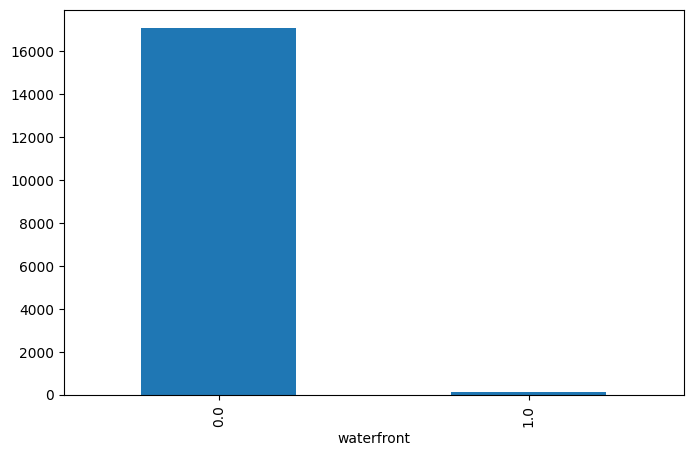

In [19]:
df_final["waterfront"].value_counts().plot(kind="bar")

In [20]:
df_final.groupby("waterfront")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
waterfront,,,,,,,,
0.000,17080.000,534260.580,343426.384,80000.000,323000.000,450000.000,640000.000,7700000.000
1.000,116.000,1723141.379,1182603.103,285000.000,785000.000,1485000.000,2325000.000,7060000.000


In [21]:
df_final[["price", "waterfront"]].head()

,price,waterfront
7316,435000.000,0.000
20586,555000.000,0.000
1040,550000.000,0.000
20543,295000.000,0.000
9587,790000.000,0.000


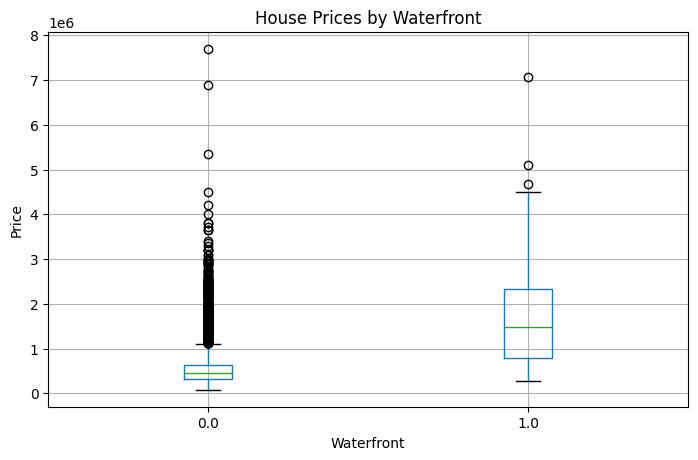

In [22]:
df_final.boxplot(column="price", by="waterfront")

plt.xlabel("Waterfront")
plt.ylabel("Price")
plt.title("House Prices by Waterfront")
plt.suptitle("")
plt.show()

In [23]:
df_final.groupby("waterfront")["price"].agg(
    count="count",
    mean="mean",
    median="median"
)

,count,mean,median
waterfront,,,
0.000,17080,534260.580,450000.000
1.000,116,1723141.379,1485000.000


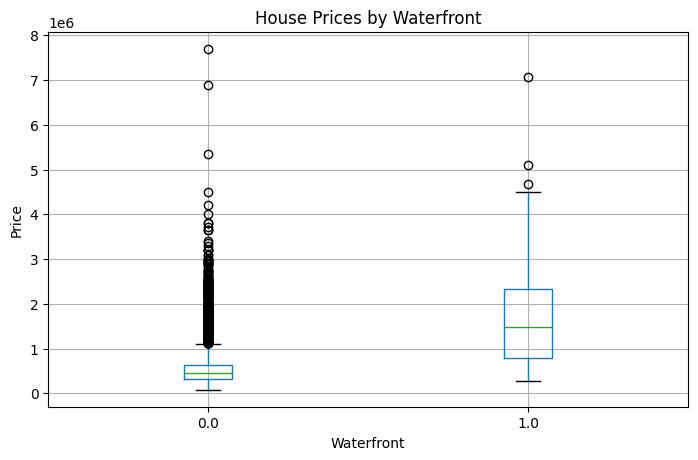

In [24]:
import matplotlib.pyplot as plt

df_final.boxplot(column="price", by="waterfront")

plt.xlabel("Waterfront")
plt.ylabel("Price")
plt.title("House Prices by Waterfront")
plt.suptitle("")
plt.show()

In [25]:
waterfront_houses = df_final[df_final["waterfront"] == 1]

In [26]:
waterfront_houses[["waterfront", "price"]]

,waterfront,price
2073,1.000,1200000.000
19089,1.000,615000.000
11213,1.000,2560000.000
4482,1.000,2000000.000
11103,1.000,1180000.000
...,...,...
1947,1.000,480000.000
6502,1.000,3650000.000
18582,1.000,570000.000
12601,1.000,2000000.000


In [27]:
waterfront_houses[["waterfront", "price"]]

,waterfront,price
2073,1.000,1200000.000
19089,1.000,615000.000
11213,1.000,2560000.000
4482,1.000,2000000.000
11103,1.000,1180000.000
...,...,...
1947,1.000,480000.000
6502,1.000,3650000.000
18582,1.000,570000.000
12601,1.000,2000000.000


In [28]:
waterfront_houses["price"].describe()

count       116.000
mean    1723141.379
std     1182603.103
min      285000.000
25%      785000.000
50%     1485000.000
75%     2325000.000
max     7060000.000
Name: price, dtype: float64

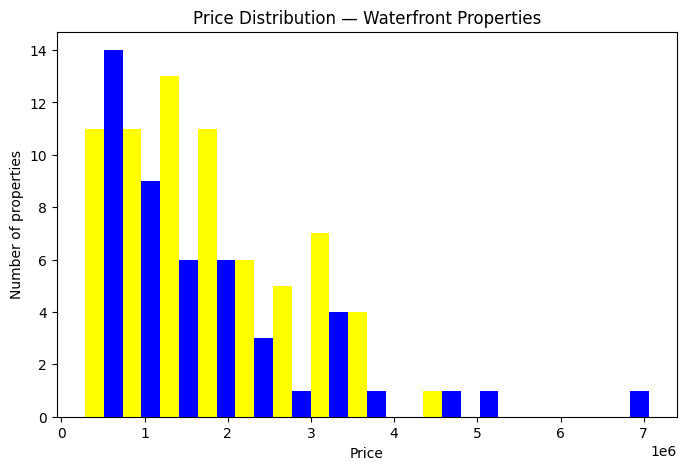

In [29]:
import matplotlib.pyplot as plt

counts, bins, patches = plt.hist(
    waterfront_houses["price"],
    bins=30
)

# Alternate yellow and blue
for i, patch in enumerate(patches):
    patch.set_facecolor("yellow" if i % 2 == 0 else "blue")

plt.xlabel("Price")
plt.ylabel("Number of properties")
plt.title("Price Distribution — Waterfront Properties")
plt.show()

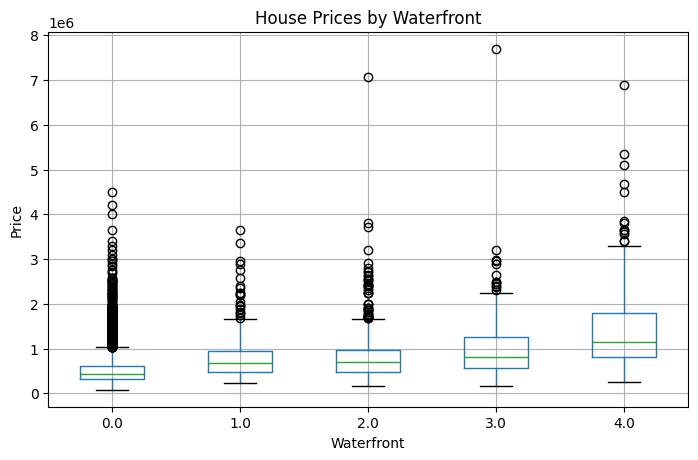

In [30]:
import matplotlib.pyplot as plt

df_final.boxplot(column="price", by="view")

plt.xlabel("Waterfront")
plt.ylabel("Price")
plt.title("House Prices by Waterfront")
plt.suptitle("")
plt.show()

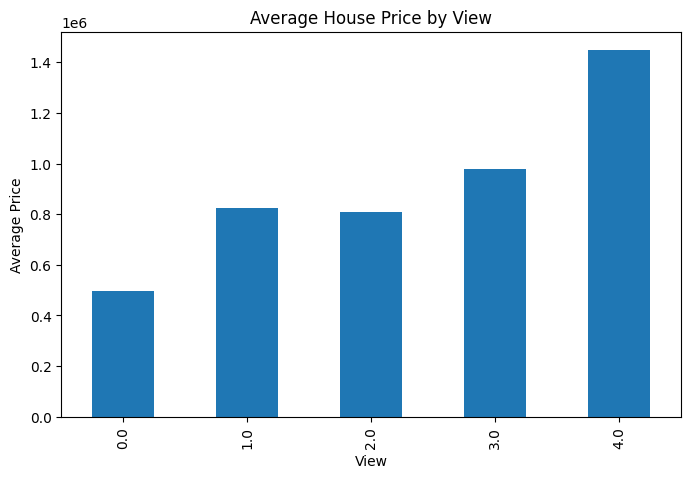

In [31]:
df_final.groupby("view")["price"].mean().plot(kind="bar")

plt.xlabel("View")
plt.ylabel("Average Price")
plt.title("Average House Price by View")
plt.show()

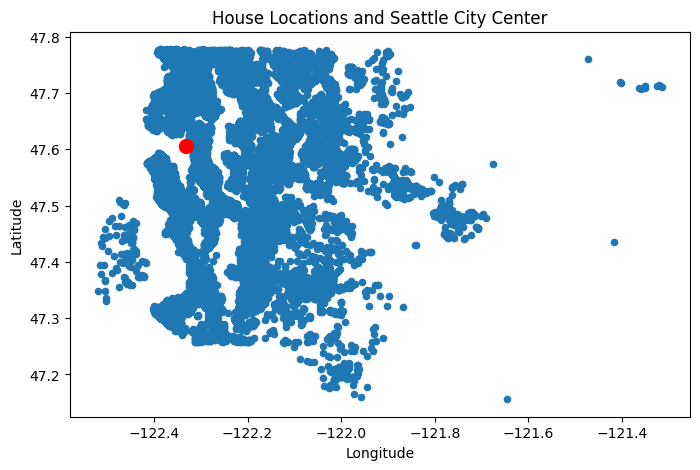

In [32]:
center_lat = 47.6062
center_long = -122.3321
df_final.plot.scatter(x="long", y="lat")

plt.scatter(center_long, center_lat, color="red", s=100)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Locations and Seattle City Center")
plt.show()

In [33]:
from geopy.distance import geodesic

def distance_from_center(row):
    return geodesic(
        (row["lat"], row["long"]),
        (center_lat, center_long)
    ).km

df_final["distance_center_km"] = df_final.apply(
    distance_from_center,
    axis=1
)

In [34]:
df_final["city_center"] = df_final["distance_center_km"].apply(
    lambda x: "Outside city center" if x > 5 else "Within city center"
)

In [35]:
df_final["city_center"].value_counts()

city_center
Outside city center    16141
Within city center      1055
Name: count, dtype: int64

In [36]:
df_final[["lat", "long", "distance_center_km", "city_center"]].head()

,lat,long,distance_center_km,city_center
7316,47.575,-122.135,15.235,Outside city center
20586,47.515,-121.870,36.224,Outside city center
1040,47.683,-122.114,18.478,Outside city center
20543,47.549,-122.363,6.782,Outside city center
9587,47.683,-122.400,9.976,Outside city center


In [37]:
high_price_limit = df_final["price"].quantile(0.99)

high_price = df_final[df_final["price"] >= high_price_limit]

print(high_price_limit)

1970499.9999999928


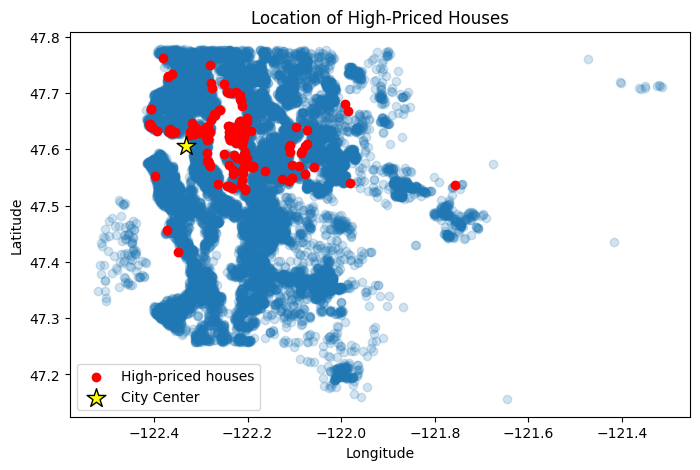

In [38]:
import matplotlib.pyplot as plt

plt.scatter(
    df_final["long"],
    df_final["lat"],
    alpha=0.2
)

plt.scatter(
    high_price["long"],
    high_price["lat"],
    color="red",
    label="High-priced houses"
)

# City center = yellow
plt.scatter(
    center_long,
    center_lat,
    color="yellow",
    edgecolor="black",
    s=200,
    marker="*",
    label="City Center"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Location of High-Priced Houses")
plt.legend()
plt.show()

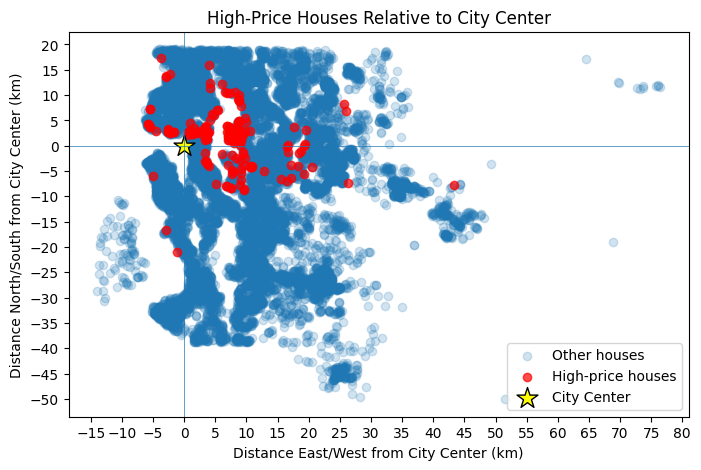

In [39]:

center_lat = 47.6062
center_long = -122.3321
from matplotlib.ticker import MultipleLocator


# Distance east/west in km
df_final["distance_x_km"] = df_final.apply(
    lambda row: geodesic(
        (center_lat, center_long),
        (center_lat, row["long"])
    ).km * (1 if row["long"] >= center_long else -1),
    axis=1
)

# Distance north/south in km
df_final["distance_y_km"] = df_final.apply(
    lambda row: geodesic(
        (center_lat, center_long),
        (row["lat"], center_long)
    ).km * (1 if row["lat"] >= center_lat else -1),
    axis=1
)

# Top 10% = high-price houses
high_price = df_final["price"] >= df_final["price"].quantile(0.99)

# Other houses
plt.scatter(
    df_final.loc[~high_price, "distance_x_km"],
    df_final.loc[~high_price, "distance_y_km"],
    alpha=0.2,
    label="Other houses"
)

# High-price houses
plt.scatter(
    df_final.loc[high_price, "distance_x_km"],
    df_final.loc[high_price, "distance_y_km"],
    color="red",
    alpha=0.7,
    label="High-price houses"
)

# City center
plt.scatter(
    0, 0,
    color="yellow",
    edgecolor="black",
    s=250,
    marker="*",
    label="City Center"
)

plt.xlabel("Distance East/West from City Center (km)")
plt.ylabel("Distance North/South from City Center (km)")
plt.title("High-Price Houses Relative to City Center")

# EVERY 2 KM
plt.gca().xaxis.set_major_locator(MultipleLocator(5))
plt.gca().yaxis.set_major_locator(MultipleLocator(5))

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)

plt.legend()
plt.show()

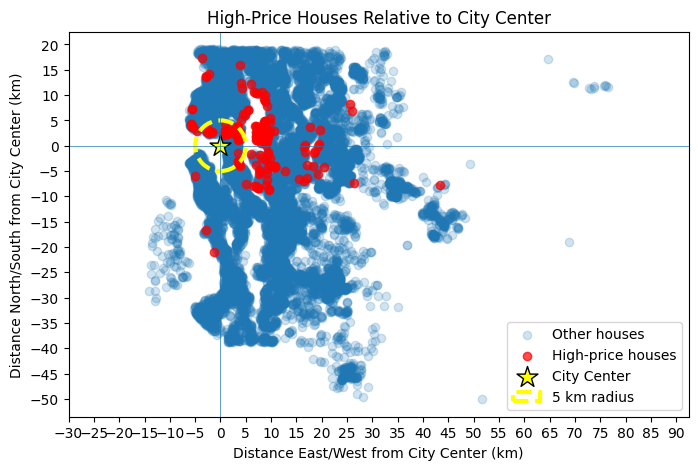

In [40]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Circle
from geopy.distance import geodesic
center_lat = 47.6062
center_long = -122.3321

# Distance east/west in km
df_final["distance_x_km"] = df_final.apply(
    lambda row: geodesic(
        (center_lat, center_long),
        (center_lat, row["long"])
    ).km * (1 if row["long"] >= center_long else -1),
    axis=1
)

# Distance north/south in km
df_final["distance_y_km"] = df_final.apply(
    lambda row: geodesic(
        (center_lat, center_long),
        (row["lat"], center_long)
    ).km * (1 if row["lat"] >= center_lat else -1),
    axis=1
)

# Top 1% = high-price houses
high_price = df_final["price"] >= df_final["price"].quantile(0.99)

# Other houses
plt.scatter(
    df_final.loc[~high_price, "distance_x_km"],
    df_final.loc[~high_price, "distance_y_km"],
    alpha=0.2,
    label="Other houses"
)

# High-price houses
plt.scatter(
    df_final.loc[high_price, "distance_x_km"],
    df_final.loc[high_price, "distance_y_km"],
    color="red",
    alpha=0.7,
    label="High-price houses"
)

# City center
plt.scatter(
    0, 0,
    color="yellow",
    edgecolor="black",
    s=250,
    marker="*",
    label="City Center"
)

# 5 km radius circle
circle = Circle(
    (0, 0),
    5,
    fill=False,
    color="YELLOW",
    linewidth=3,
    linestyle="--",
    label="5 km radius"
)

plt.gca().add_patch(circle)

# Labels and title
plt.xlabel("Distance East/West from City Center (km)")
plt.ylabel("Distance North/South from City Center (km)")
plt.title("High-Price Houses Relative to City Center")

# Every 5 km
plt.gca().xaxis.set_major_locator(MultipleLocator(5))
plt.gca().yaxis.set_major_locator(MultipleLocator(5))

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)

# Keep circle round
plt.axis("equal")

plt.legend()
plt.show()